<a href="https://colab.research.google.com/github/Rushikeshaya/Generative-AI/blob/main/Rushikesh_Hande_GenerativeAILabAssignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Neural Network Implementation from Scratch

## Generative AI Lab


**Name:** RushikeshHande          
**PRN Number:** 202401110056              
**Batch:** A3  
**Department:** CSE AIML  
**Course:** Generative AI Lab  
**Date of Submission:** 15/08/2026

## Part A: Problem Definition & Methodology

**1. Dataset:**
We are using the **Iris Dataset**, a classic dataset in machine learning. It contains 150 samples of iris flowers, with 4 features (sepal length, sepal width, petal length, petal width) and 3 target classes representing the species of the flower (Setosa, Versicolor, Virginica).

**2. Task:**
This is a **classification problem**. The goal is to classify the species of the iris flower based on its 4 physical features.

**3. Methodology:**
* **Neural Network Architecture:**
  * Input Layer: 4 neurons (matching the 4 features).
  * Hidden Layer: 1 hidden layer with 5 neurons using the Sigmoid activation function.
  * Output Layer: 3 neurons (matching the 3 classes) using the Softmax activation function.
* **Forward Pass:** Data is passed through the network by calculating the dot product of inputs and weights, adding biases, and passing the result through activation functions (Sigmoid for hidden, Softmax for output).
* **Backpropagation:** We calculate the error at the output and propagate it backward using the chain rule to compute gradients.
* **Loss Function:** Categorical Cross-Entropy is used since this is a multi-class classification task.
* **Optimization:** We use standard Gradient Descent to update the weights and minimize the loss.

## Part 1: Setup and Data Preparation
In this section, we import the necessary libraries (excluding deep learning frameworks) and prepare the **Iris Dataset**.
The data preparation steps include:
* **Standardization:** Scaling features so they have a mean of 0 and a variance of 1.
* **One-Hot Encoding:** Converting the target labels into a binary matrix for multi-class classification.
* **Train-Test Split:** Dividing the dataset to evaluate model performance on unseen data.

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# 1. Load the dataset
iris = load_iris()
X = iris.data
y = iris.target.reshape(-1, 1)

# 2. Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. One-hot encode the target variables
encoder = OneHotEncoder(sparse_output=False)
y_encoded = encoder.fit_transform(y)

# 4. Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_encoded, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape} | y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape} | y_test shape: {y_test.shape}")

X_train shape: (120, 4) | y_train shape: (120, 3)
X_test shape: (30, 4) | y_test shape: (30, 3)


## Part 2: Activation and Loss Functions
Before building the network architecture, we define the core mathematical functions required for the forward and backward passes.

In [15]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def sigmoid_derivative(z):
    s = sigmoid(z)
    return s * (1 - s)

def softmax(z):
    # Subtracting max(z) for numerical stability to prevent overflow
    exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

def compute_loss(y_true, y_pred):
    samples = y_true.shape[0]
    # Clipping predictions to prevent log(0) errors
    y_pred = np.clip(y_pred, 1e-7, 1 - 1e-7)
    return -np.sum(y_true * np.log(y_pred)) / samples

## Part 3: Defining the Neural Network Class
This class encapsulates the network's parameters and training logic.

In [17]:
class NeuralNetwork:
    def __init__(self, input_size, hidden_size, output_size, learning_rate=0.1):
        self.learning_rate = learning_rate

        # Initialize Weights and Biases
        self.W1 = np.random.randn(input_size, hidden_size) * 0.01
        self.b1 = np.zeros((1, hidden_size))

        self.W2 = np.random.randn(hidden_size, output_size) * 0.01
        self.b2 = np.zeros((1, output_size))

        self.loss_history = []

    def forward(self, X):
        # Hidden Layer
        self.Z1 = np.dot(X, self.W1) + self.b1
        self.A1 = sigmoid(self.Z1)

        # Output Layer
        self.Z2 = np.dot(self.A1, self.W2) + self.b2
        self.A2 = softmax(self.Z2)

        return self.A2

    def backward(self, X, y_true):
        samples = X.shape[0]

        # Gradients for Output Layer
        dZ2 = self.A2 - y_true
        dW2 = np.dot(self.A1.T, dZ2) / samples
        db2 = np.sum(dZ2, axis=0, keepdims=True) / samples

        # Gradients for Hidden Layer
        dA1 = np.dot(dZ2, self.W2.T)
        dZ1 = dA1 * sigmoid_derivative(self.Z1)
        dW1 = np.dot(X.T, dZ1) / samples
        db1 = np.sum(dZ1, axis=0, keepdims=True) / samples

        # Gradient Descent Updates
        self.W2 -= self.learning_rate * dW2
        self.b2 -= self.learning_rate * db2
        self.W1 -= self.learning_rate * dW1
        self.b1 -= self.learning_rate * db1

    def train(self, X, y, epochs):
        for epoch in range(epochs):
            y_pred = self.forward(X)
            loss = compute_loss(y, y_pred)
            self.loss_history.append(loss)
            self.backward(X, y)

            if epoch % 100 == 0:
                print(f"Epoch {epoch} | Loss: {loss:.4f}")

    def predict(self, X):
        y_pred = self.forward(X)
        return np.argmax(y_pred, axis=1)

## Part 4: Training the Model
We instantiate the neural network with 4 input neurons, 5 hidden neurons, and 3 output neurons. We then train it over 1000 epochs.

In [12]:
# Instantiate the model
nn = NeuralNetwork(input_size=4, hidden_size=5, output_size=3, learning_rate=0.1)

# Train the model
print("Starting Training Process...")
nn.train(X_train, y_train, epochs=1000)
print("Training Completed")

Starting Training Process...
Epoch 0 | Loss: 1.0986
Epoch 100 | Loss: 1.0933
Epoch 200 | Loss: 0.9077
Epoch 300 | Loss: 0.6133
Epoch 400 | Loss: 0.4967
Epoch 500 | Loss: 0.4303
Epoch 600 | Loss: 0.3777
Epoch 700 | Loss: 0.3327
Epoch 800 | Loss: 0.2940
Epoch 900 | Loss: 0.2607
Training Completed


## Part 5: Model Evaluation
After training, we evaluate the model's accuracy on both the training and testing datasets to ensure it has generalized well and is not overfitting.

In [13]:
# Predictions on training data
y_pred_train = nn.predict(X_train)
y_true_train = np.argmax(y_train, axis=1)
train_accuracy = np.mean(y_pred_train == y_true_train) * 100

# Predictions on testing data
y_pred_test = nn.predict(X_test)
y_true_test = np.argmax(y_test, axis=1)
test_accuracy = np.mean(y_pred_test == y_true_test) * 100

print(f"Training Accuracy: {train_accuracy:.2f}%")
print(f"Testing Accuracy: {test_accuracy:.2f}%")

Training Accuracy: 95.83%
Testing Accuracy: 96.67%


## Part 6: Visualizing the Loss Curve
Plotting the loss over our epochs helps us visually verify that Gradient Descent successfully minimized the error during training.

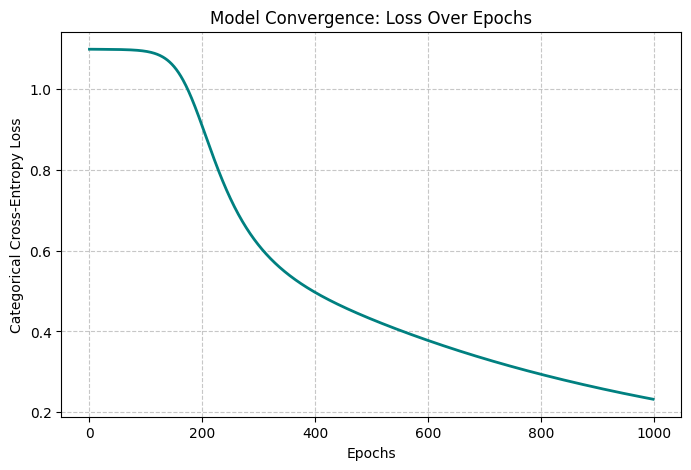

In [14]:
plt.figure(figsize=(8, 5))
plt.plot(nn.loss_history, color='teal', linewidth=2)
plt.title("Model Convergence: Loss Over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Categorical Cross-Entropy Loss")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()